<img src="./Imagenes/logo_UTN.svg" align="right" width="150" />

#### Teoría de los Circuitos II

# Trabajo semanal 5
#### Alumno:    Lucas Gallero
#### Profesor:  Mariano Llamedo Soria  
#### Ayudante de TPs:    David Moharos
----

# Enunciado:

A continuación se muestran dos circuitos conocidos mediante un esquema de tres nodos externos. Para el análisis de la red se permite definir nodos internos.

<div align="center">
    <img src="./Imagenes/enunciado.png" alt="Enunciado del trabajo semanal" width="700"/>
</div>

Se pide:

1. Construir la **Matriz de Admitancia Indefinida** para cada circuito. Para el BS170 se debe plantear el modelo lineal visto en clase, utilizando admitancias y un generador de corriente que considere $C_{iss}$, $C_{oss}$, $C_{rss}$ y $g_m$.

2. Para la red $T$:
   - Obtener $\dfrac{V_{23}}{V_{13}}$, $\dfrac{V_{21}}{V_{31}}$ y $\dfrac{V_{12}}{V_{32}}$, explicitando el armado de los cofactores de segundo orden.
   - Graficar módulo y fase de cada transferencia y analizar si dos de ellas cumplen $|T_a+T_b|=1$.

3. Para el MOS:
   - Obtener los parámetros $Y$ en configuración **source común** y **drain común**.
   - Calcular la matriz de parámetros $ABCD$ en configuración source común.

**Bonus:**

- Implementar en Python la MAI y la obtención del inciso 2.a con los módulos de PyTC2.
- Simular circuitalmente y medir los parámetros $Y$ del MOS en drain común utilizando el modelo SPICE del BS170.

.MODEL BS170 NMOS (

+ VTO=1.824 

+ KP=0.123 

+ LAMBDA=0.012 

+ RD=1.2 

+ RS=1.2 

+ RG=10 

+ CBD=18p 

+ CBS=0 

+ CJ=0 

+ CJO=24p 

+ CGSO=30p 

+ CGDO=10p 

+ IS=1e-14 

+ PB=0.8 

+ MJ=0.5 

+ FC=0.5

+)



*-------------------------------------------------------------------

* BS170 SPICE Model (Vishay / Siliconix)

* Includes non-linear Ciss, Coss, Crss capacitances & Body Diode

* Node 1: Drain (D) | Node 2: Gate (G) | Node 3: Source (S)

*-------------------------------------------------------------------

.SUBCKT BS170 1 2 3

M1 9 7 8 8 MM L=10u W=30u

D1 8 1 D_BODY

RG 2 7 10

RD 1 9 1.15

RS 3 8 0.15

CGS 7 8 24.5p

CGD 7 1 3.5p

DBODY 8 1 D_BD

.MODEL MM NMOS (

+ LEVEL = 3

+ VTO   = 2.1

+ KP    = 0.38

+ THETA = 0.08

+ VMAX  = 1.5e5

+ ETA   = 0.015

+)

.MODEL D_BODY D (

+ IS    = 1e-13

+ RS    = 0.1

+ N     = 1.0

+ BV    = 60

+ IBV   = 10u

+)

.MODEL D_BD D (

+ IS    = 1e-15

+ CJO   = 28p

+ VJ    = 0.8

+ M     = 0.5

+)

.ENDS BS170

In [1]:
# PyTC2: la librería para TC2
from pytc2.cuadripolos import calc_MAI_vtransf_ij_mn

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Math, Markdown
from pathlib import Path
import subprocess


sp.init_printing()

# Las librerías que utilizaremos se cargan una sola vez.

---

# Resolución

# <ins>1) Matriz de Admitancia Indefinida de la red $T$

La red posee tres nodos externos y un nodo interno. Se adopta la siguiente numeración:

| Nodo | Descripción |
|---:|---|
| $1$ | Terminal izquierdo |
| $2$ | Terminal derecho |
| $3$ | Terminal inferior |
| $4$ | Unión interna entre los inductores y el capacitor |

En el dominio de Laplace, las admitancias son:

$$
y_L=\frac{1}{sL}
$$

$$
y_C=sC
$$

Para una rama de admitancia $y$ conectada entre los nodos $i$ y $j$, el aporte a la MAI es:

$$
\begin{array}{c|cc}
 & i & j\\ \hline
i & +y & -y\\
j & -y & +y
\end{array}
$$

En esta red se tienen las ramas:

$$
(1,4):y_L,\qquad (2,4):y_L,\qquad (3,4):y_C
$$

Por lo tanto:

$$
\boxed{
\mathbf{Y}_{T}=\begin{bmatrix}
y_L&0&0&-y_L\\
0&y_L&0&-y_L\\
0&0&y_C&-y_C\\
-y_L&-y_L&-y_C&2y_L+y_C
\end{bmatrix}}
$$

Reemplazando las admitancias:

$$
\boxed{
\mathbf{Y}_{T}=\begin{bmatrix}
\frac{1}{sL}&0&0&-\frac{1}{sL}\\
0&\frac{1}{sL}&0&-\frac{1}{sL}\\
0&0&sC&-sC\\
-\frac{1}{sL}&-\frac{1}{sL}&-sC&\frac{2}{sL}+sC
\end{bmatrix}}
$$

La suma de cada fila y de cada columna debe ser cero. En consecuencia, el determinante de la MAI también debe ser nulo.

In [2]:
# Variables simbólicas
s = sp.symbols('s', complex=True)
L, C = sp.symbols('L C', real=True, positive=True)

yL = 1/(s*L)
yC = s*C

# MAI de la red T. Orden: nodos 1, 2, 3 e interno 4.
Y_T = sp.Matrix([
    [ yL,   0,   0,  -yL],
    [  0,  yL,   0,  -yL],
    [  0,   0,  yC,  -yC],
    [-yL, -yL, -yC, 2*yL + yC]
])

display(Math(r'\mathbf{Y}_T=' + sp.latex(Y_T)))

suma_filas = [sp.simplify(valor) for valor in Y_T*sp.ones(4, 1)]
suma_columnas = [sp.simplify(valor) for valor in Y_T.T*sp.ones(4, 1)]
determinante = sp.simplify(Y_T.det())

print('Suma de filas:', suma_filas)
print('Suma de columnas:', suma_columnas)
print('Determinante:', determinante)

if suma_filas == [0, 0, 0, 0]:
    print('✓ La suma de todas las filas es cero.')
else:
    print('✗ La suma de las filas no es cero.')

if suma_columnas == [0, 0, 0, 0]:
    print('✓ La suma de todas las columnas es cero.')
else:
    print('✗ La suma de las columnas no es cero.')

if determinante == 0:
    print('✓ El determinante es cero.')
else:
    print('✗ El determinante no es cero.')

<IPython.core.display.Math object>

Suma de filas: [0, 0, 0, 0]
Suma de columnas: [0, 0, 0, 0]
Determinante: 0
✓ La suma de todas las filas es cero.
✓ La suma de todas las columnas es cero.
✓ El determinante es cero.


---
# 2.a) Transferencias de la red $T$ mediante cofactores de segundo orden

Al elegir un nodo de referencia se elimina una fila y una columna de la MAI. Para obtener una transferencia de tensión se calcula luego un cofactor de esa matriz reducida.

Por lo tanto, respecto de la MAI original de orden cuatro, se eliminan en total dos filas y dos columnas. Los determinantes resultantes son **cofactores de segundo orden**.

## <ins>Transferencia $T_1=\dfrac{V_{23}}{V_{13}}$

Se toma el nodo $3$ como referencia y se conserva el orden $(1,2,4)$:

$$
\mathbf{Y}_{(3)}=
\begin{bmatrix}
y_L&0&-y_L\\
0&y_L&-y_L\\
-y_L&-y_L&2y_L+y_C
\end{bmatrix}
$$

La entrada se aplica en el nodo $1$ y la salida se observa en el nodo $2$:

$$
\frac{V_{23}}{V_{13}}=\frac{C_{12}^{(3)}}{C_{11}^{(3)}}
$$

El cofactor del denominador es:

$$
C_{11}^{(3)}=
\begin{vmatrix}
y_L&-y_L\\
-y_L&2y_L+y_C
\end{vmatrix}
$$

$$
C_{11}^{(3)}=y_L(2y_L+y_C)-y_L^2
$$

$$
\boxed{C_{11}^{(3)}=y_L(y_L+y_C)}
$$

El cofactor del numerador es:

$$
C_{12}^{(3)}=(-1)^{1+2}
\begin{vmatrix}
0&-y_L\\
-y_L&2y_L+y_C
\end{vmatrix}
$$

$$
\boxed{C_{12}^{(3)}=y_L^2}
$$

Entonces:

$$
\frac{V_{23}}{V_{13}}=\frac{y_L}{y_L+y_C}
$$

Reemplazando $y_L=1/(sL)$ e $y_C=sC$:

$$
\boxed{
T_1(s)=\frac{V_{23}}{V_{13}}=\frac{1}{1+s^2LC}}
$$

## <ins>Transferencia $T_2=\dfrac{V_{21}}{V_{31}}$

Se toma el nodo $1$ como referencia y se conserva el orden $(2,3,4)$:

$$
\mathbf{Y}_{(1)}=
\begin{bmatrix}
y_L&0&-y_L\\
0&y_C&-y_C\\
-y_L&-y_C&2y_L+y_C
\end{bmatrix}
$$

El nodo de entrada $3$ ocupa la segunda posición y el nodo de salida $2$ la primera. Por ello:

$$
\frac{V_{21}}{V_{31}}=\frac{C_{21}^{(1)}}{C_{22}^{(1)}}
$$

$$
C_{22}^{(1)}=
\begin{vmatrix}
y_L&-y_L\\
-y_L&2y_L+y_C
\end{vmatrix}
=y_L(y_L+y_C)
$$

$$
C_{21}^{(1)}=(-1)^{2+1}
\begin{vmatrix}
0&-y_L\\
-y_C&2y_L+y_C
\end{vmatrix}
=y_Ly_C
$$

Por lo tanto:

$$
\boxed{
T_2(s)=\frac{V_{21}}{V_{31}}=\frac{s^2LC}{1+s^2LC}}
$$

## <ins>Transferencia $T_3=\dfrac{V_{12}}{V_{32}}$

Ahora se toma el nodo $2$ como referencia. La matriz restante, en el orden $(1,3,4)$, es idéntica a la anterior. En consecuencia aparecen los mismos cofactores:

$$
C_{22}^{(2)}=y_L(y_L+y_C)
$$

$$
C_{21}^{(2)}=y_Ly_C
$$

Entonces:

$$
\boxed{
T_3(s)=\frac{V_{12}}{V_{32}}=\frac{s^2LC}{1+s^2LC}}
$$

Se observa que, por la simetría de los dos inductores:

$$
\boxed{T_2(s)=T_3(s)}
$$

In [3]:
# PyTC2 numera los nodos desde cero:
# 0 -> nodo 1
# 1 -> nodo 2
# 2 -> nodo 3
# 3 -> nodo interno 4

# verbose=False evita mostrar los cálculos internos.
T1 = sp.factor(
    calc_MAI_vtransf_ij_mn(
        Y_T, 1, 2, 0, 2,
        verbose=False
    )
)

T2 = sp.factor(
    calc_MAI_vtransf_ij_mn(
        Y_T, 1, 0, 2, 0,
        verbose=False
    )
)

T3 = sp.factor(
    calc_MAI_vtransf_ij_mn(
        Y_T, 0, 1, 2, 1,
        verbose=False
    )
)

display(Markdown('### Transferencias obtenidas'))

display(Math(
    r'\boxed{'
    r'T_1(s)=\frac{V_{23}}{V_{13}}='
    + sp.latex(T1)
    + r'}'
))

display(Math(
    r'\boxed{'
    r'T_2(s)=\frac{V_{21}}{V_{31}}='
    + sp.latex(T2)
    + r'}'
))

display(Math(
    r'\boxed{'
    r'T_3(s)=\frac{V_{12}}{V_{32}}='
    + sp.latex(T3)
    + r'}'
))

# Expresiones teóricas esperadas
T1_esperada = 1/(1 + s**2*L*C)
T2_esperada = s**2*L*C/(1 + s**2*L*C)

verificacion_T1 = sp.simplify(T1 - T1_esperada) == 0
verificacion_T2 = sp.simplify(T2 - T2_esperada) == 0
verificacion_T3 = sp.simplify(T3 - T2) == 0
verificacion_complementariedad = (
    sp.simplify(T1 + T2 - 1) == 0
)

if (
    verificacion_T1
    and verificacion_T2
    and verificacion_T3
    and verificacion_complementariedad
):
    display(Markdown(
        '**✓ Las transferencias y la complementariedad '
        'fueron verificadas correctamente.**'
    ))
else:
    display(Markdown(
        '**✗ Alguna de las verificaciones no se cumplió.**'
    ))

### Transferencias obtenidas

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**✓ Las transferencias y la complementariedad fueron verificadas correctamente.**

---
# 2.b) Respuesta de módulo y fase

Se define la frecuencia natural de la red:

$$
\boxed{\omega_0=\frac{1}{\sqrt{LC}}}
$$

y la frecuencia normalizada:

$$
x=\frac{\omega}{\omega_0}
$$

Al reemplazar $s=j\omega$:

$$
s^2LC=-\omega^2LC=-x^2
$$

Las transferencias quedan:

$$
\boxed{T_1(j\omega)=\frac{1}{1-x^2}}
$$

$$
\boxed{T_2(j\omega)=T_3(j\omega)=\frac{-x^2}{1-x^2}}
$$

Sus módulos son:

$$
|T_1|=\frac{1}{|1-x^2|}
$$

$$
|T_2|=|T_3|=\frac{x^2}{|1-x^2|}
$$

Para $0<\omega<\omega_0$, $T_1$ es positiva y $T_2=T_3$ son negativas. Para $\omega>\omega_0$ ocurre lo contrario.

En $\omega=\omega_0$ el denominador se anula. Como la red es ideal y no posee pérdidas, aparece una singularidad de resonancia.

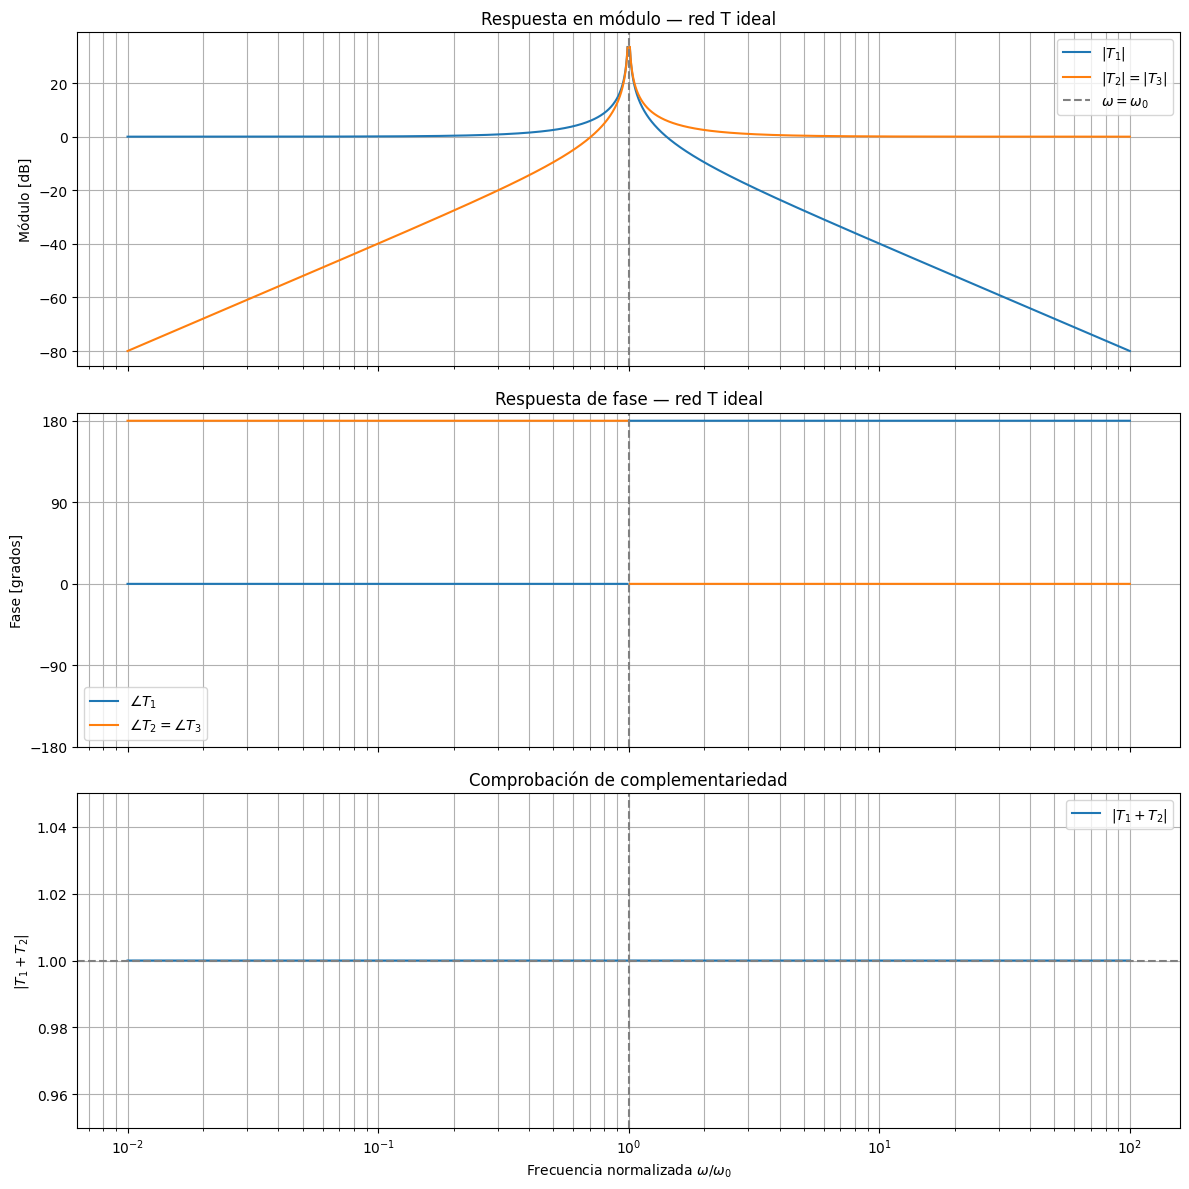

In [4]:
# Respuesta normalizada de la red T
x = np.logspace(-2, 2, 3000)
den = 1 - x**2

# Se excluye una pequeña zona alrededor de la resonancia ideal.
zona_resonancia = np.abs(den) < 2e-2

T1_jw = np.where(zona_resonancia, np.nan, 1/den).astype(complex)
T2_jw = np.where(zona_resonancia, np.nan, -x**2/den).astype(complex)

mag_T1 = 20*np.log10(np.abs(T1_jw))
mag_T2 = 20*np.log10(np.abs(T2_jw))
fase_T1 = np.angle(T1_jw, deg=True)
fase_T2 = np.angle(T2_jw, deg=True)

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].semilogx(x, mag_T1, label=r'$|T_1|$')
axes[0].semilogx(x, mag_T2, label=r'$|T_2|=|T_3|$')
axes[0].axvline(1, color='gray', linestyle='--', label=r'$\omega=\omega_0$')
axes[0].set_ylabel('Módulo [dB]')
axes[0].set_title('Respuesta en módulo — red T ideal')
axes[0].grid(True, which='both')
axes[0].legend()

axes[1].semilogx(x, fase_T1, label=r'$\angle T_1$')
axes[1].semilogx(x, fase_T2, label=r'$\angle T_2=\angle T_3$')
axes[1].axvline(1, color='gray', linestyle='--')
axes[1].set_ylabel('Fase [grados]')
axes[1].set_title('Respuesta de fase — red T ideal')
axes[1].set_yticks([-180, -90, 0, 90, 180])
axes[1].grid(True, which='both')
axes[1].legend()

complementariedad = np.where(zona_resonancia, np.nan, np.abs(T1_jw + T2_jw))
axes[2].semilogx(x, complementariedad, label=r'$|T_1+T_2|$')
axes[2].axhline(1, color='gray', linestyle='--')
axes[2].axvline(1, color='gray', linestyle='--')
axes[2].set_xlabel(r'Frecuencia normalizada $\omega/\omega_0$')
axes[2].set_ylabel(r'$|T_1+T_2|$')
axes[2].set_ylim(0.95, 1.05)
axes[2].set_title('Comprobación de complementariedad')
axes[2].grid(True, which='both')
axes[2].legend()

fig.tight_layout()
plt.show()

## <ins>Análisis de las respuestas

| Rango | $T_1$ | $T_2=T_3$ |
|---|---|---|
| $\omega\ll\omega_0$ | $T_1\rightarrow1$ | $T_2,T_3\rightarrow0$ |
| $\omega=\omega_0$ | No definida | No definida |
| $\omega\gg\omega_0$ | $T_1\rightarrow0$ | $T_2,T_3\rightarrow1$ |

La complementariedad se comprueba algebraicamente:

$$
T_1(s)+T_2(s)=
\frac{1}{1+s^2LC}+
\frac{s^2LC}{1+s^2LC}
$$

$$
\boxed{T_1(s)+T_2(s)=1}
$$

Por lo tanto:

$$
\boxed{|T_1+T_2|=1}
$$

Como $T_2=T_3$, también se cumple $|T_1+T_3|=1$. Esto no debe confundirse con $|T_1|+|T_2|=1$, que no se cumple en general.

---
# 3) Modelo incremental del MOS BS170

Se utiliza el modelo incremental de alta frecuencia con los terminales:

$$
1=G,\qquad 2=D,\qquad 3=S
$$

<div align="center">
    <img src="./Imagenes/modelo_mos_bs170.png" alt="Modelo incremental del BS170" width="600"/>
</div>

Las capacitancias informadas por el datasheet son combinaciones de las capacitancias físicas entre terminales:

$$
C_{iss}=C_{gs}+C_{gd}
$$

$$
C_{oss}=C_{ds}+C_{gd}
$$

$$
C_{rss}=C_{gd}
$$

De aquí:

$$
\boxed{C_{gd}=C_{rss}}
$$

$$
\boxed{C_{gs}=C_{iss}-C_{rss}}
$$

$$
\boxed{C_{ds}=C_{oss}-C_{rss}}
$$

Con los valores utilizados para el modelo lineal:

$$
C_{iss}=24pF,\qquad C_{oss}=17pF,\qquad C_{rss}=7pF
$$

se obtiene:

$$
\boxed{C_{gd}=7pF,\qquad C_{gs}=17pF,\qquad C_{ds}=10pF}
$$

La fuente dependiente posee el valor:

$$
i_m=g_mv_{gs}=g_m(V_1-V_3)
$$

y está orientada desde drain hacia source.

# 3.1) Matriz de Admitancia Indefinida del MOS

Se definen:

$$
y_{gd}=sC_{gd},\qquad y_{gs}=sC_{gs},\qquad y_{ds}=sC_{ds}
$$

Las corrientes se consideran entrando al dispositivo.

## <ins>Ecuación del nodo 1 — Gate

$$
I_1=y_{gd}(V_1-V_2)+y_{gs}(V_1-V_3)
$$

$$
I_1=(y_{gd}+y_{gs})V_1-y_{gd}V_2-y_{gs}V_3
$$

## <ins>Ecuación del nodo 2 — Drain

$$
I_2=y_{gd}(V_2-V_1)+y_{ds}(V_2-V_3)+g_m(V_1-V_3)
$$

$$
I_2=(g_m-y_{gd})V_1+(y_{gd}+y_{ds})V_2-(g_m+y_{ds})V_3
$$

## <ins>Ecuación del nodo 3 — Source

$$
I_3=y_{gs}(V_3-V_1)+y_{ds}(V_3-V_2)-g_m(V_1-V_3)
$$

$$
I_3=-(g_m+y_{gs})V_1-y_{ds}V_2+(g_m+y_{gs}+y_{ds})V_3
$$

Por lo tanto:

$$
\boxed{
\mathbf{Y}_{MOS}=\begin{bmatrix}
y_{gd}+y_{gs}&-y_{gd}&-y_{gs}\\
g_m-y_{gd}&y_{gd}+y_{ds}&-g_m-y_{ds}\\
-g_m-y_{gs}&-y_{ds}&g_m+y_{gs}+y_{ds}
\end{bmatrix}}
$$

Reemplazando las admitancias:

$$
\boxed{
\mathbf{Y}_{MOS}=\begin{bmatrix}
s(C_{gd}+C_{gs})&-sC_{gd}&-sC_{gs}\\
g_m-sC_{gd}&s(C_{gd}+C_{ds})&-g_m-sC_{ds}\\
-g_m-sC_{gs}&-sC_{ds}&g_m+s(C_{gs}+C_{ds})
\end{bmatrix}}
$$

La matriz no es simétrica porque la fuente dependiente hace que el MOS sea una red no recíproca.

In [5]:
gm = sp.symbols('g_m', real=True, positive=True)

Cgs, Cgd, Cds = sp.symbols(
    'C_gs C_gd C_ds',
    real=True,
    positive=True
)

Y_MOS = sp.Matrix([
    [ s*(Cgd + Cgs),  -s*Cgd,        -s*Cgs             ],
    [ gm - s*Cgd,     s*(Cgd + Cds), -gm - s*Cds        ],
    [ -gm - s*Cgs,    -s*Cds,        gm + s*(Cgs + Cds) ]
])

display(Math(r'\mathbf{Y}_{MOS}=' + sp.latex(Y_MOS)))

suma_filas_mos = [
    sp.simplify(valor)
    for valor in Y_MOS * sp.ones(3, 1)
]

suma_columnas_mos = [
    sp.simplify(valor)
    for valor in Y_MOS.T * sp.ones(3, 1)
]

determinante_mos = sp.simplify(Y_MOS.det())

print('Suma de filas:', suma_filas_mos)
print('Suma de columnas:', suma_columnas_mos)
print('Determinante:', determinante_mos)

if suma_filas_mos == [0, 0, 0]:
    print('✓ La suma de todas las filas es cero.')
else:
    print('✗ La suma de las filas no es cero.')

if suma_columnas_mos == [0, 0, 0]:
    print('✓ La suma de todas las columnas es cero.')
else:
    print('✗ La suma de las columnas no es cero.')

if determinante_mos == 0:
    print('✓ El determinante es cero.')
else:
    print('✗ El determinante no es cero.')

# Valores de capacitancia del modelo lineal
tabla_capacitancias = pd.DataFrame({
    'Capacitancia': [
        r'$C_{gd}$',
        r'$C_{gs}$',
        r'$C_{ds}$'
    ],
    'Valor [pF]': [7, 17, 10]
})

display(tabla_capacitancias)

<IPython.core.display.Math object>

Suma de filas: [0, 0, 0]
Suma de columnas: [0, 0, 0]
Determinante: 0
✓ La suma de todas las filas es cero.
✓ La suma de todas las columnas es cero.
✓ El determinante es cero.


,Capacitancia,Valor [pF]
0,$C_{gd}$,7
1,$C_{gs}$,17
2,$C_{ds}$,10


---
# 3.a) Parámetros $Y$ en configuración source común

El source, nodo $3$, se toma como terminal común:

$$
V_3=0
$$

Los puertos quedan definidos como:

$$
v_1=V_{13}=V_{GS},\qquad v_2=V_{23}=V_{DS}
$$

Para obtener la matriz definida se elimina de la MAI la fila y la columna correspondientes al nodo $3$:

$$
\boxed{
\mathbf{Y}_{SC}=\begin{bmatrix}
s(C_{gd}+C_{gs})&-sC_{gd}\\
g_m-sC_{gd}&s(C_{gd}+C_{ds})
\end{bmatrix}}
$$

Utilizando las capacitancias del datasheet:

$$
\boxed{
\mathbf{Y}_{SC}=\begin{bmatrix}
sC_{iss}&-sC_{rss}\\
g_m-sC_{rss}&sC_{oss}
\end{bmatrix}}
$$

Por lo tanto:

$$
y_{11}^{SC}=sC_{iss},\qquad y_{12}^{SC}=-sC_{rss}
$$

$$
y_{21}^{SC}=g_m-sC_{rss},\qquad y_{22}^{SC}=sC_{oss}
$$

Con los valores utilizados:

$$
\boxed{
\mathbf{Y}_{SC}=\begin{bmatrix}
s(24pF)&-s(7pF)\\
g_m-s(7pF)&s(17pF)
\end{bmatrix}}
$$

# 3.a) Parámetros $Y$ en configuración drain común

Ahora el drain, nodo $2$, se toma como terminal común:

$$
V_2=0
$$

Los puertos son:

$$
v_1=V_{12}=V_{GD},\qquad v_2=V_{32}=V_{SD}
$$

Se eliminan de la MAI la fila y la columna del nodo $2$, conservando los nodos $(1,3)$:

$$
\boxed{
\mathbf{Y}_{DC}=\begin{bmatrix}
s(C_{gd}+C_{gs})&-sC_{gs}\\
-g_m-sC_{gs}&g_m+s(C_{gs}+C_{ds})
\end{bmatrix}}
$$

En función de las capacitancias del datasheet:

$$
\boxed{
\mathbf{Y}_{DC}=\begin{bmatrix}
sC_{iss}&-s(C_{iss}-C_{rss})\\
-g_m-s(C_{iss}-C_{rss})&g_m+s(C_{iss}+C_{oss}-2C_{rss})
\end{bmatrix}}
$$

Con los valores utilizados:

$$
\boxed{
\mathbf{Y}_{DC}=\begin{bmatrix}
s(24pF)&-s(17pF)\\
-g_m-s(17pF)&g_m+s(27pF)
\end{bmatrix}}
$$

In [6]:
# Reducción directa de la MAI eliminando el nodo común.
Y_SC = Y_MOS.extract([0, 1], [0, 1])  # source común: se elimina el nodo 3
Y_DC = Y_MOS.extract([0, 2], [0, 2])  # drain común: se elimina el nodo 2

display(Math(r'\mathbf{Y}_{SC}=' + sp.latex(Y_SC)))
display(Math(r'\mathbf{Y}_{DC}=' + sp.latex(Y_DC)))

pF = sp.Rational(1, 10**12)
valores_C = {Cgd: 7*pF, Cgs: 17*pF, Cds: 10*pF}

display(Math(r'\mathbf{Y}_{SC,BS170}=' + sp.latex(Y_SC.subs(valores_C))))
display(Math(r'\mathbf{Y}_{DC,BS170}=' + sp.latex(Y_DC.subs(valores_C))))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
# 3.b) Matriz de parámetros $ABCD$ en source común

Se adopta la convención de transmisión:

$$
\boxed{
\begin{bmatrix}
V_1\\I_1
\end{bmatrix}
=
\begin{bmatrix}
A&B\\C&D
\end{bmatrix}
\begin{bmatrix}
V_2\\-I_2
\end{bmatrix}}
$$

Partiendo de:

$$
I_2=y_{21}V_1+y_{22}V_2
$$

se despeja:

$$
V_1=-\frac{y_{22}}{y_{21}}V_2+\frac{1}{y_{21}}I_2
$$

Por comparación:

$$
A=-\frac{y_{22}}{y_{21}},\qquad B=-\frac{1}{y_{21}}
$$

Luego:

$$
I_1=y_{11}V_1+y_{12}V_2
$$

Al reemplazar $V_1$ y definir:

$$
\Delta_Y=y_{11}y_{22}-y_{12}y_{21}
$$

se obtiene:

$$
C=-\frac{\Delta_Y}{y_{21}},\qquad D=-\frac{y_{11}}{y_{21}}
$$

Para el MOS en source común:

$$
\Delta_Y=s g_mC_{rss}+s^2(C_{iss}C_{oss}-C_{rss}^2)
$$

Finalmente:

$$
\boxed{
\mathbf{T}_{SC}=\begin{bmatrix}
-\dfrac{sC_{oss}}{g_m-sC_{rss}}&-\dfrac{1}{g_m-sC_{rss}}\\[4mm]
-\dfrac{s g_mC_{rss}+s^2(C_{iss}C_{oss}-C_{rss}^2)}{g_m-sC_{rss}}&-\dfrac{sC_{iss}}{g_m-sC_{rss}}
\end{bmatrix}}
$$

Las unidades son:

$$
[A]=[D]=1,\qquad [B]=\Omega,\qquad [C]=S
$$

In [7]:
# Conversión simbólica de Y a ABCD con la convención [V2, -I2].
y11, y12 = Y_SC[0, 0], Y_SC[0, 1]
y21, y22 = Y_SC[1, 0], Y_SC[1, 1]

Delta_Y = sp.factor(Y_SC.det())

ABCD_SC = sp.Matrix([
    [-y22/y21,       -1/y21],
    [-Delta_Y/y21,   -y11/y21]
]).applyfunc(sp.factor)

display(Math(r'\Delta_Y=' + sp.latex(Delta_Y)))
display(Math(r'\mathbf{T}_{SC}=' + sp.latex(ABCD_SC)))

# Comprobación dimensional simbólica del determinante de transmisión.
det_ABCD = sp.factor(ABCD_SC.det())
display(Math(r'AD-BC=' + sp.latex(det_ABCD)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---

# Bonus — Simulación SPICE de los parámetros $Y$ en drain común

Se implementó el modelo suministrado del BS170 en [`bs170_detailed.lib`](./Simulacion/bs170_detailed.lib). El circuito principal se encuentra en [`Simulacion.asc`](./Simulacion/Simulacion.asc).

<div align="center">
    <img src="./Imagenes/CTO.png" alt="Circuito del BS170" width="800"/>
</div>


Como el punto de polarización no fue indicado en el enunciado, se adopta:

$$
V_D=10V,\qquad V_G=5V,\qquad V_S=2V
$$

Por lo tanto:

$$
V_{GS}=3V,\qquad V_{DS}=8V
$$

El drain queda a masa de pequeña señal mediante una fuente con valor `AC 0`. En LTspice se utiliza la directiva:

```spice
.net V(S,D) VG
```

Esta directiva define al gate como puerto de entrada y al source como puerto de salida, ambos referidos al drain. De esta manera LTspice genera directamente las trazas `Y11(VG)`, `Y12(VG)`, `Y21(VG)` y `Y22(VG)`.

Para conservar $V_S=2V$ en continua sin cortocircuitar el puerto de salida en alterna, la polarización del source se aplica mediante un inductor $L_{BIAS}=1TH$.

Para la verificación automática con ngspice se realizan dos ensayos:

| Ensayo | $V_1=V_{GD}$ | $V_2=V_{SD}$ | Parámetros obtenidos |
|---|---:|---:|---|
| Excitación de gate | $1V$ | $0V$ | $y_{11}$, $y_{21}$ |
| Excitación de source | $0V$ | $1V$ | $y_{12}$, $y_{22}$ |

Como ngspice define la corriente de una fuente de tensión desde su terminal positivo hacia el negativo, las corrientes entrando al MOS se calculan como:

$$
I_G=-I(V_G),\qquad I_S=-I(V_S)
$$

El barrido se realiza desde $10Hz$ hasta $1GHz$.

In [12]:
# Ejecución de ngspice y armado de la matriz Y medida.
base = Path.cwd() / 'Simulacion'
netlist = base/'medicion_y_drain_comun.cir'

candidatos_ngspice = [
    Path(r'C:\msys64\ucrt64\bin\ngspice_con.exe'),
    Path(r'C:\Program Files\ngspice\bin\ngspice_con.exe'),
]

ngspice = next((ruta for ruta in candidatos_ngspice if ruta.exists()), None)

if ngspice is None:
    raise FileNotFoundError('No se encontró ngspice_con.exe.')

resultado_spice = subprocess.run(
    [str(ngspice), '-n', '-b', str(netlist.name)],
    cwd=base,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    encoding='utf-8',
    errors='replace',
    check=False,
)

if resultado_spice.returncode != 0:
    print(resultado_spice.stdout)
    raise RuntimeError('La simulación SPICE no finalizó correctamente.')

# Se muestran solamente las líneas relevantes del punto de operación.
for linea in resultado_spice.stdout.splitlines():
    texto = linea.strip().lower()
    if texto.startswith(('v(d)', 'v(g)', 'v(s)', 'i(vd)', 'i(vg)', 'i(vs)')):
        print(linea)

def leer_wrdata(nombre, parametro_1, parametro_2):
    datos = np.loadtxt(base/nombre, skiprows=1)
    return pd.DataFrame({
        'frecuencia_hz': datos[:, 0],
        parametro_1: datos[:, 1] + 1j*datos[:, 2],
        parametro_2: datos[:, 3] + 1j*datos[:, 4],
    })

ensayo_gate = leer_wrdata(
    'y_drain_comun_ensayo_gate.txt', 'y11', 'y21'
)
ensayo_source = leer_wrdata(
    'y_drain_comun_ensayo_source.txt', 'y12', 'y22'
)

assert np.allclose(
    ensayo_gate['frecuencia_hz'], ensayo_source['frecuencia_hz']
)

frecuencias = ensayo_gate['frecuencia_hz'].to_numpy()
indice_1MHz = int(np.argmin(np.abs(frecuencias - 1e6)))

Y_medido = np.array([
    [ensayo_gate.loc[indice_1MHz, 'y11'], ensayo_source.loc[indice_1MHz, 'y12']],
    [ensayo_gate.loc[indice_1MHz, 'y21'], ensayo_source.loc[indice_1MHz, 'y22']],
], dtype=complex)

filas = []
for i, nombre_fila in enumerate(('Gate', 'Source')):
    for j, nombre_columna in enumerate(('Gate', 'Source')):
        valor = Y_medido[i, j]
        filas.append({
            'Parámetro': f'y{i+1}{j+1}',
            'Parte real [S]': valor.real,
            'Parte imaginaria [S]': valor.imag,
            'Módulo [S]': abs(valor),
            'Fase [°]': np.angle(valor, deg=True),
        })

tabla_Y = pd.DataFrame(filas)
display(tabla_Y)

def numero_a_latex(valor):
    # Presenta números pequeños en notación científica.
    if np.isclose(valor, 0.0, atol=1e-15):
        return '0'

    exponente = int(np.floor(np.log10(abs(valor))))

    if -2 <= exponente <= 1:
        return f'{valor:.6g}'

    mantisa = valor/10**exponente
    return rf'{mantisa:.5g}\times10^{{{exponente}}}'

def complejo_a_latex(valor):
    parte_real = numero_a_latex(valor.real)
    parte_imaginaria = numero_a_latex(abs(valor.imag))
    signo = '+' if valor.imag >= 0 else '-'
    return rf'{parte_real}{signo}j\,{parte_imaginaria}'

latex_Y = (
    r'\boxed{\mathbf{Y}_{DC,sim}(1\,\mathrm{MHz})='
    r'\begin{bmatrix}'
    f'{complejo_a_latex(Y_medido[0, 0])} & '
    f'{complejo_a_latex(Y_medido[0, 1])}'
    r'\\'
    f'{complejo_a_latex(Y_medido[1, 0])} & '
    f'{complejo_a_latex(Y_medido[1, 1])}'
    r'\end{bmatrix}\;\mathrm{S}}'
)

display(Markdown(r'### Matriz $Y$ medida a $1\,\mathrm{MHz}$'))
display(Math(latex_Y))

# Archivo final con todo el barrido.
datos_completos = pd.DataFrame({'frecuencia_hz': frecuencias})
for nombre, serie in (
    ('y11', ensayo_gate['y11']),
    ('y12', ensayo_source['y12']),
    ('y21', ensayo_gate['y21']),
    ('y22', ensayo_source['y22']),
):
    datos_completos[f'{nombre}_real_s'] = np.real(serie)
    datos_completos[f'{nombre}_imag_s'] = np.imag(serie)
    datos_completos[f'{nombre}_mod_s'] = np.abs(serie)
    datos_completos[f'{nombre}_fase_deg'] = np.angle(serie, deg=True)

datos_completos.to_csv(base/'parametros_y_drain_comun.csv', index=False)
display(Markdown(
    '✓ Se generó `parametros_y_drain_comun.csv` con '
    f'**{len(datos_completos)} frecuencias**.'
))

v(d) = 1.000000e+01
v(g) = 5.000000e+00
v(s) = 2.000000e+00
i(vd) = -3.69481e-01
i(vg) = 0.000000e+00
i(vs) = 3.694812e-01


,Parámetro,Parte real [S],Parte imaginaria [S],Módulo [S],Fase [°]
0,y11,2.561332e-07,0.000159,0.000159,89.907815
1,y12,-2.222185e-07,-0.000137,0.000137,-90.092798
2,y21,-7.413969e-01,0.001064,0.741398,179.917805
3,y22,7.414233e-01,-0.000853,0.741424,-0.065937


### Matriz $Y$ medida a $1\,\mathrm{MHz}$

<IPython.core.display.Math object>

✓ Se generó `parametros_y_drain_comun.csv` con **801 frecuencias**.

---

## <ins> verificación de los parámetros $Y$

Mediante la directiva `.net V(S,D) VG`, LTspice calculó directamente los cuatro parámetros $Y$ del BS170 en configuración drain común. Las siguientes figuras muestran las respuestas de módulo y fase obtenidas entre $10Hz$ y $1GHz$.

<div style="display:flex; gap:16px; align-items:flex-start;">
  <div style="width:100%; text-align:center;">
    <img src="./Imagenes/Y11.png" alt="Módulo y fase de Y11" width="200%"/>
    <b>Figura 1 — Módulo y fase de $Y_{11}$.</b>
  </div>
  </div>
  <div style="width:100%; text-align:center;">
    <img src="./Imagenes/Y12.png" alt="Módulo y fase de Y12" width="200%"/>
    <b>Figura 2 — Módulo y fase de $Y_{12}$.</b>
  </div>
</div>

<div style="display:flex; gap:16px; align-items:flex-start; margin-top:18px;">
  <div style="width:100%; text-align:center;">
    <img src="./Imagenes/Y21.png" alt="Módulo y fase de Y21" width="200%"/>
    <b>Figura 3 — Módulo y fase de $Y_{21}$.</b>
</div>

</div>
  <div style="width:100%; text-align:center;">
    <img src="./Imagenes/Y22.png" alt="Módulo y fase de Y22" width="200%"/>
    <b>Figura 4 — Módulo y fase de $Y_{22}$.</b>
  </div>
</div>

Los cursores se ubicaron aproximadamente en $1MHz$. Los valores medidos fueron:

| Parámetro | Frecuencia | Módulo | Fase |
|---|---:|---:|---:|
| $Y_{11}$ | $1.0000MHz$ | $-75.9598dB$ | $89.9078^{\circ}$ |
| $Y_{12}$ | $1.0026MHz$ | $-77.2287dB$ | $-90.0931^{\circ}$ |
| $Y_{21}$ | $1.0078MHz$ | $-2.6058dB$ | $179.9172^{\circ}$ |
| $Y_{22}$ | $1.0001MHz$ | $-2.6011dB$ | $-0.0660^{\circ}$ |

Para convertir los resultados de LTspice a forma compleja se utiliza:

$$
|Y|=10^{Y_{dB}/20}
$$

$$
Y=|Y|\left(\cos\phi+j\sin\phi\right)
$$

Aplicando estas expresiones, la matriz medida resulta:

$$
\boxed{
\mathbf{Y}_{DC,sim}\approx
\begin{bmatrix}
2.562\times10^{-7}+j1.59224\times10^{-4}&
-2.235\times10^{-7}-j1.37582\times10^{-4}\\
-0.740818+j1.0712\times10^{-3}&
0.741216-j8.537\times10^{-4}
\end{bmatrix}S}
$$

La parte real de $Y_{21}$ permite obtener:

$$
g_m^{(21)}=-\operatorname{Re}\{Y_{21}\}=0.740818S
$$

mientras que de $Y_{22}$ se obtiene:

$$
g_m^{(22)}=\operatorname{Re}\{Y_{22}\}=0.741216S
$$

Ambas estimaciones difieren solamente un $0.054\%$, por lo que puede adoptarse:

$$
\boxed{g_m\approx0.7410S}
$$

A partir de las partes imaginarias de $Y_{11}$ e $Y_{12}$ también pueden obtenerse capacitancias efectivas:

$$
C_{iss,ef}=\frac{\operatorname{Im}\{Y_{11}\}}{2\pi f}\approx25.34pF
$$

$$
C_{gs,ef}=-\frac{\operatorname{Im}\{Y_{12}\}}{2\pi f}\approx21.84pF
$$

Por lo tanto:

$$
\boxed{C_{gd,ef}=C_{iss,ef}-C_{gs,ef}\approx3.50pF}
$$

Este resultado coincide con el valor `CGD=3.5p` incluido en el modelo SPICE detallado.

Las curvas de $Y_{11}$ e $Y_{12}$ presentan inicialmente una pendiente cercana a $20dB/dec$ y fases próximas a $+90^{\circ}$ y $-90^{\circ}$, respectivamente, verificando su comportamiento predominantemente capacitivo. En cambio, $Y_{21}$ e $Y_{22}$ mantienen un módulo prácticamente constante y fases próximas a $180^{\circ}$ y $0^{\circ}$, debido al predominio de los términos $-g_m$ y $g_m$.

A frecuencias elevadas aparecen variaciones de módulo y fase que no están contempladas por el modelo ideal de tres capacitancias. Estas diferencias se deben a que el subcircuito completo también incluye $R_G$, $R_D$, $R_S$.

En conclusión, la simulación verifica los signos, las fases y los términos dominantes de la matriz analítica de drain común. La coincidencia de las dos estimaciones de $g_m$ y la recuperación de $C_{gd}\approx3.5pF$ confirman que la medición mediante parámetros de red fue realizada correctamente.

---
# <ins>Conclusión

Se construyeron las matrices de admitancia indefinida de la red $T$ y del modelo incremental del BS170, verificando en ambos casos las propiedades fundamentales de una MAI:

- La suma de cada fila es cero.
- La suma de cada columna es cero.
- El determinante es nulo.

Para la red $T$ se obtuvieron las tres transferencias mediante cofactores de segundo orden y se comprobó que:

$$
\boxed{T_1+T_2=1}
$$

Para el MOS se obtuvieron los parámetros $Y$ en configuraciones source común y drain común, además de la matriz $ABCD$ en source común.

Finalmente, los resultados analíticos fueron verificados con PyTC2. Los parámetros $Y$ del BS170 se obtuvieron directamente en LTspice mediante `.net` y se contrastaron con dos ensayos AC automatizados en ngspice.

---

# <ins> Resolución manuscrita:

## <ins>TS5.pdf:

In [14]:
from IPython.display import IFrame
IFrame("Imagenes/TS5.pdf", width=1000, height=700)